In [7]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)


In [8]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 500
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [9]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 7407 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [10]:
incv3_5 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3))
incv3_5.trainable = False
for layer in incv3_5.layers[-20:]:
    layer.trainable = True
model_5 = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  layers.Rescaling(1./127.5, offset=-1),
  incv3_5,
  layers.GlobalAveragePooling2D(),
  layers.BatchNormalization(),
  layers.Dense((128),activation='gelu',
                   kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),

               ),
  layers.Dropout(0.4),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])
model_5.summary()
keras.backend.clear_session(free_memory=True)
model_5.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,280 (84.21 MB)

 Trainable params: 2,202,760 (8.40 MB)

 Non-trainable params: 19,871,520 (75.80 MB)

In [11]:
history_5 = model_5.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
          validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        )]        )

Epoch 1/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - loss: 2.1639 - sparse_categorical_accuracy: 0.3081 - val_loss: 1.3495 - val_sparse_categorical_accuracy: 0.6164
Epoch 2/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.4318 - sparse_categorical_accuracy: 0.5368 - val_loss: 0.9652 - val_sparse_categorical_accuracy: 0.6950
Epoch 3/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.1835 - sparse_categorical_accuracy: 0.6206 - val_loss: 0.8479 - val_sparse_categorical_accuracy: 0.7358
Epoch 4/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.0321 - sparse_categorical_accuracy: 0.6695 - val_loss: 0.7787 - val_sparse_categorical_accuracy: 0.7547
Epoch 5/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.9379 - sparse_categorical_accuracy: 0.7004 - val_loss: 0.7379 - val_sparse_categorical_accuracy: 0.7642
Epoch 6/500
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.8607 - sparse_categorical_accuracy: 0.7246 - val_loss: 0.7061 - val_sparse_categorical_accuracy

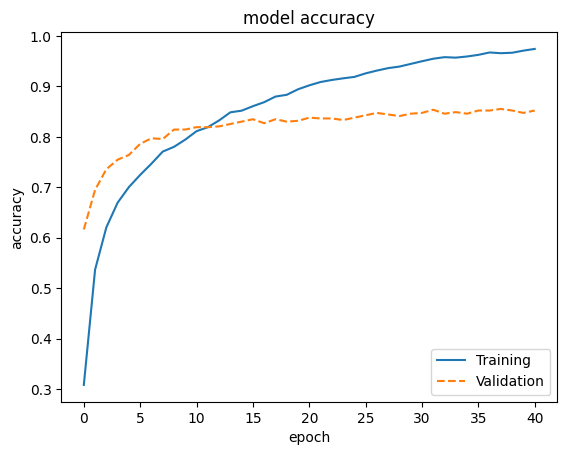

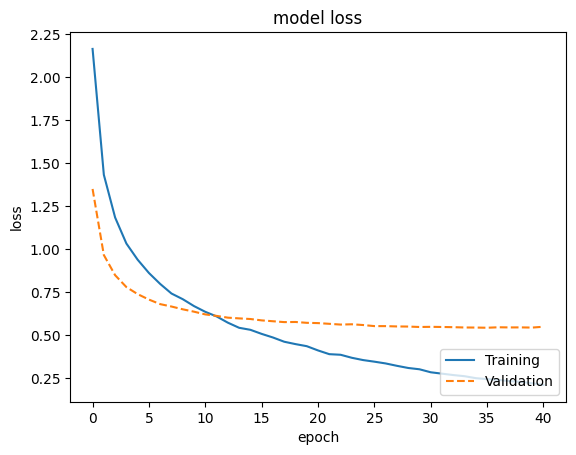

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5216 - sparse_categorical_accuracy: 0.8522


[0.5215590596199036, 0.8522012829780579]

In [12]:
plt.plot(history_5.history['sparse_categorical_accuracy'])
plt.plot(history_5.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()
model_5.evaluate(test_ds)